# EBM training and testing

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# The star of the show: Explainable Boosting Machine
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show


In [49]:
# 1 : Load
df_long = pd.read_csv('../Data/dataREanonymized_long.csv')

# 2 : Finding the subjects with non-null discharge_mrs values
valid_subjects = df_long[
    (df_long['variable'] == 'discharge_mrs') &
    (df_long['Value'].notna())
]['subject_id'].unique()

# 3 : Filter the DataFrame to only include valid subjects
df_long_filtered = df_long[df_long['subject_id'].isin(valid_subjects)]

# 4 : Pivot to Wide format
df_wide = df_long_filtered.pivot(index='subject_id', columns='variable', values='Value').reset_index()

# 5 : Keep only rows where stroke_type is "ischemic"
df_wide = df_wide[df_wide['stroke_type'] == 'ischemic']
df_wide = df_wide[df_wide['thrombolysis'] == '1']


C:\Users\2432741\AppData\Local\Temp\ipykernel_25084\890118506.py:2: DtypeWarning: Columns (0: Value) have mixed types. Specify dtype option on import or set low_memory=False.
  df_long = pd.read_csv('../Data/dataREanonymized_long.csv')


In [50]:
# ---------------------------------------------------------
# CELL 3: FEATURE ENGINEERING
# ---------------------------------------------------------

# Anticoagulants discharge
anticoagulants_during_discharge = ['discharge_apixaban', 'discharge_dabigatran', 'discharge_edoxaban', 'discharge_rivaroxaban', 'discharge_warfarin', 'discharge_heparin']
df_wide['anticoagulant_discharge'] = df_wide[anticoagulants_during_discharge].max(axis=1)
df_wide = df_wide.drop(columns=anticoagulants_during_discharge)

# Anticoagulants before onset
anticoagulants_before_onset = ['before_onset_warfarin']
df_wide['anticoagulant_before_onset'] = df_wide[anticoagulants_before_onset].max(axis=1)
df_wide = df_wide.drop(columns=anticoagulants_before_onset)

# Vitals and times
df_wide['sys_blood_pressure'] = pd.cut(pd.to_numeric(df_wide['sys_blood_pressure'], errors='coerce'), bins=[-np.inf, 111, 180, np.inf], labels=[0, 1, 2], right=False)
df_wide['dis_blood_pressure'] = pd.cut(pd.to_numeric(df_wide['dis_blood_pressure'], errors='coerce'), bins=[-np.inf, 105, np.inf], labels=[0, 1], right=False)
df_wide['glucose'] = pd.cut(pd.to_numeric(df_wide['glucose'], errors='coerce'), bins=[-np.inf, 60, 141, np.inf], labels=[0, 1, 2], right=False)
df_wide['cholesterol'] = pd.cut(pd.to_numeric(df_wide['cholesterol'], errors='coerce'), bins=[-np.inf, 70, 101, np.inf], labels=[0, 1, 2], right=False)
df_wide['prestroke_mrs'] = pd.cut(pd.to_numeric(df_wide['prestroke_mrs'], errors='coerce'), bins=[-np.inf, 2, 3, np.inf], labels=[0, 1, 2], right=False)
df_wide['onset_to_door'] = pd.cut(pd.to_numeric(df_wide['onset_to_door'], errors='coerce'), bins=[-np.inf, 4.5, 24, np.inf], labels=[0, 1, 2], right=True)
df_wide['door_to_imaging'] = pd.cut(pd.to_numeric(df_wide['door_to_imaging'], errors='coerce'), bins=[-np.inf, 20, np.inf], labels=[0, 1], right=True)
df_wide['door_to_needle'] = pd.cut(pd.to_numeric(df_wide['door_to_needle'], errors='coerce'), bins=[-np.inf, 30, 45, 60, np.inf], labels=[0, 1, 2, 3], right=True)

# Force numeric conversion
for col in ['sys_blood_pressure', 'dis_blood_pressure', 'glucose', 'cholesterol', 'prestroke_mrs', 'onset_to_door', 'door_to_imaging', 'door_to_needle']:
    df_wide[col] = pd.to_numeric(df_wide[col])


In [51]:
# ---------------------------------------------------------
# CELL 4: TARGET AND SPLIT
# ---------------------------------------------------------
target_raw = pd.to_numeric(df_wide['three_m_mrs'], errors='coerce')
valid_target = target_raw.notna()

y = target_raw[valid_target].astype(int)

colonnes_a_jeter = ['discharge_mrs', 'three_m_mrs', 'stroke_type', 'thrombolysis']
X = df_wide.loc[valid_target].drop(columns=[col for col in colonnes_a_jeter if col in df_wide.columns])

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.dropna(how='all', axis=1)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Split complete. Train: {len(X_train)} patients, Test: {len(X_test)} patients.")

Split complete. Train: 259 patients, Test: 65 patients.


In [52]:
# ---------------------------------------------------------
# CELL 5: KNN IMPUTATION
# ---------------------------------------------------------
categorical_candidates = [
    'nihss_score', 'sys_blood_pressure', 'dis_blood_pressure', 'glucose',
    'cholesterol', 'prestroke_mrs', 'onset_to_door', 'door_to_imaging',
    'door_to_needle', 'anticoagulant_discharge', 'anticoagulant_before_onset'
]
cat_features_valides = [col for col in categorical_candidates if col in X_train.columns]
num_features = [col for col in X_train.columns if col not in cat_features_valides]

imputer = KNNImputer(n_neighbors=5)
X_train_num_imputed = pd.DataFrame(imputer.fit_transform(X_train[num_features]), columns=num_features, index=X_train.index)
X_test_num_imputed = pd.DataFrame(imputer.transform(X_test[num_features]), columns=num_features, index=X_test.index)

for col in cat_features_valides:
    X_train_num_imputed[col] = X_train[col].fillna(-1).astype(int)
    X_test_num_imputed[col] = X_test[col].fillna(-1).astype(int)

X_train = X_train_num_imputed
X_test = X_test_num_imputed
print("Missing values imputed successfully.")

Missing values imputed successfully.


In [53]:
# Initialize the Explainable Boosting Regressor
# interactions=10 tells the model to automatically find the 10 most critical 
# feature combinations (e.g., Age + NIHSS)
ebm_model = ExplainableBoostingRegressor(random_state=42, interactions=10)

# Train the model
ebm_model.fit(X_train, y_train)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,10
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.04
,greedy_ratio,10.0


--- 6. MODEL PERFORMANCE ---
Mean Absolute Error (MAE): 1.38 mRS points
Strict Accuracy (Exact Match): 36.92%
CLINICAL ACCURACY (+/- 1 point): 61.54%



<Figure size 800x600 with 0 Axes>

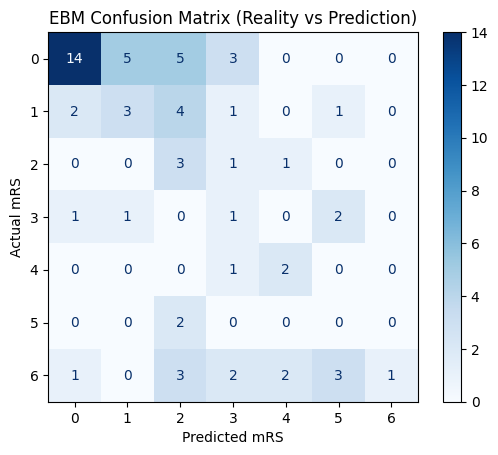

In [54]:
# ---------------------------------------------------------
# CELL 7: CLINICAL EVALUATION
# ---------------------------------------------------------
print("--- 6. MODEL PERFORMANCE ---")

# Predict raw scores and round them to nearest mRS integer (0-6)
y_pred_raw = ebm_model.predict(X_test)
y_pred_arrondi = np.round(y_pred_raw).clip(0, 6).astype(int)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_raw)
accuracy_stricte = accuracy_score(y_test, y_pred_arrondi)

# Clinical Accuracy (Tolerance of +/- 1 point)
ecarts = np.abs(y_test.values - y_pred_arrondi)
accuracy_plus_moins_1 = np.mean(ecarts <= 1)

print(f"Mean Absolute Error (MAE): {mae:.2f} mRS points")
print(f"Strict Accuracy (Exact Match): {accuracy_stricte * 100:.2f}%")
print(f"CLINICAL ACCURACY (+/- 1 point): {accuracy_plus_moins_1 * 100:.2f}%\n")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_arrondi, labels=[0, 1, 2, 3, 4, 5, 6])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4, 5, 6])
disp.plot(cmap='Blues', values_format='d')
plt.title("EBM Confusion Matrix (Reality vs Prediction)")
plt.xlabel("Predicted mRS")
plt.ylabel("Actual mRS")
plt.show()

In [55]:
# ---------------------------------------------------------
# CELL 8: MODEL INTERPRETABILITY (THE GLASS BOX)
# ---------------------------------------------------------
print("--- 7. EXPLAINING THE AI DECISIONS ---")

# 1. Global Explanation (Feature Importance & Risk Curves)
print("Generating Global Dashboard...")
ebm_global = ebm_model.explain_global(name='Global mRS Predictor')
show(ebm_global) 
# Note: Click on "Summary" to see feature importance.
# Click on individual features (like Age) to see the exact risk curve.

# 2. Local Explanation (Why did patient X get score Y?)
print("Generating Local Patient Analysis...")
# Let's explain the first 5 patients in the test set
patients_to_explain = X_test.iloc[:5]
actual_mrs_scores = y_test.iloc[:5]

ebm_local = ebm_model.explain_local(patients_to_explain, actual_mrs_scores, name='Patient Level Analysis')
show(ebm_local)

--- 7. EXPLAINING THE AI DECISIONS ---
Generating Global Dashboard...


<!-- http://127.0.0.1:7001/1663284349984/ -->

Generating Local Patient Analysis...


<!-- http://127.0.0.1:7001/1663283702800/ -->

1. Le Dashboard Global (Importance des variables)
Son fonctionnement : C'est le résumé de l'expérience du modèle sur l'ensemble de la cohorte. Ce graphique classe tes variables cliniques (NIHSS, âge, volume, etc.) de la plus influente à la moins influente.
Ce qu'il faut retenir : Il ne dit pas comment une variable agit, mais à quel point elle est cruciale pour le modèle en général. C'est l'équivalent du "Feature Importance" classique, parfait pour rassurer les médecins sur le fait que le modèle accorde de l'importance aux bons critères médicaux.

2. Les Courbes de Risque Non-Linéaires (ex: l'impact du NIHSS)
Son fonctionnement : En zoomant sur une variable spécifique depuis le dashboard global, ce graphique montre exactement comment cette variable impacte le score mRS. L'axe horizontal représente la valeur clinique (ex: le score NIHSS de 0 à 42), et l'axe vertical montre le "score de risque" (en points) ajouté ou retiré à la prédiction finale.
Ce qu'il faut retenir : C'est ici que l'EBM brille. Ce graphique prouve que le modèle comprend les nuances de la médecine. Par exemple, il peut montrer qu'un score NIHSS bas a peu d'impact, mais qu'une fois un certain seuil franchi, le risque de handicap (mRS) explose subitement.

3. Le Dashboard Local (L'explication par patient)
Son fonctionnement : C'est la vue "au chevet du patient". Il s'agit d'un graphique en barres (souvent appelé waterfall chart) qui déconstruit la prédiction pour un seul patient précis. On part d'un score de base (la moyenne de la population), puis chaque barre montre comment les caractéristiques spécifiques du patient (ex: "âge = 75 ans" ou "hypertension = Oui") viennent tirer le score mRS vers le haut (aggravation) ou vers le bas (amélioration).
Ce qu'il faut retenir : La somme mathématique de toutes ces barres donne exactement la prédiction finale. C'est l'outil ultime de décision partagée : un médecin peut auditer toute la logique du modèle en un coup d'œil.

4. Le Menu de Sélection et d'Audit (Actual, Predicted, Residual)
Son fonctionnement : Ce tableau de bord permet de naviguer dans tes patients de test pour confronter la réalité (Actual mRS) à la machine (Predicted mRS), ce qui donne l'erreur du modèle (Residual).
Ce qu'il faut retenir : Il te sert de microscope pour analyser les "ratés" du modèle. En triant les patients par leurs résidus les plus élevés, tu peux cliquer dessus pour voir leur Dashboard Local. C'est grâce à cet outil que tu peux identifier les cas complexes ou les biais algorithmiques (comme les biais liés à la sélection de l'âge) et montrer au jury que tu sais faire preuve d'esprit critique face aux erreurs de ton intelligence artificielle.